Для 1 лаб работы по CV необходимо реализовать базовый минимум операций над изображениями
Входное изображение в формате (RGB, не чёрно-белое)
1. Фильтры

1.1 Медианный фильтр

1.2 Фильтр гаусса

2. Морфологические операции

2.1 Эрозия

2.2 Дилатация

3. Прочие операции

3.1 пороговая бинаризация (для rgb и grayscale изображения)

3.2 выравнивание гистограммы

3.3 поворот изображений на угол кратный 90 градусов


In [1]:
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import time
from tqdm import tqdm #
from numba import jit, prange

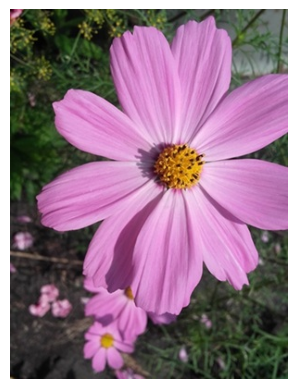

In [2]:
image1 = mpimg.imread('../Sourse_Images/flowers_sm_sz3.jpg')#salt_paper0.jpg
plt.imshow(image1)
plt.axis('off')  # скрыть оси
plt.show()

In [3]:
print(f"Размер: {image1.shape}")
print(f"Тип данных: {image1.dtype}")

Размер: (400, 300, 3)
Тип данных: uint8


# 1. Фильтры

## 1.1 Медианный фильтр

In [42]:
def Median_filter(image: np.ndarray, filtersize: int = 3, expand: int = 0, grout: bool = False, verbose: bool = False) -> np.ndarray:
    """
    image - исходное изображение массив np.ndarray (Н, W, C) H-высота, W - ширина, C - число каналов
    filtersize - размер стороны ядра свёртки, должно быть нечётное число
    expand - расширение изображение
    expand = 0 - не расширяет 
    expand = 1 - зеркало с дублированием края
    expand = 2 - зеркало без дублирования края
    verbose - вывод массивов, по которым происходит выбор
    grout - выбирать большее значение за медиану, только при expand = 0
    
    """
    H = image.shape[0]
    W = image.shape[1]
    C = image.shape[2]
    edge = 1
    if (filtersize % 2 and filtersize > 0):
        edge = (filtersize - 1) // 2
    else:
        ####Error
        raise ValueError("Размер ядра должен быть нечетным числом")
        # res_image = np.zeros((H, W, C))

    # kernel = np.zeros((filtersize, filtersize))
    buf_image = np.zeros((H + 2 * edge, W + 2 * edge, C), dtype=image.dtype)  # np.uint8

    buf_image[edge: H + edge, edge: W + edge, :] = image #image.copy()

    if expand == 0:
        res_image = np.zeros((H, W, C), dtype=image.dtype)  # dtype=image.dtype)
        
        for i in range(H):
            for j in range(W):
                for k in range(C):
                    value_array = np.zeros(1, dtype=image.dtype)#dtype=np.uint8
                    flag_first = True
                    for jl in range(2 * edge + 1):
                        for il in range(2 * edge + 1):
                            H_i = i - edge + il
                            W_j = j - edge + jl

                            if(H_i >=0 and W_j >=0 and H_i < H and W_j < W):
                                element = image[H_i, W_j, k]
                                if (flag_first == True):
                                    value_array[0] = element
                                    flag_first = False
                                else:
                                    arr_len = len(value_array)
                                    for pos in range(arr_len):
                                        if (value_array[pos] >= element):
                                            value_array1 = np.insert(value_array, pos, element)
                                            value_array = value_array1
                                            break
                                        elif (pos == arr_len - 1):
                                            value_array1 = np.append(value_array, element)
                                            value_array = value_array1
                            else:
                                continue
                    if (verbose):
                        for q in range(len(value_array)):
                            print(f"{value_array[q]} ", end='')
                        print()
                    arr_len = len(value_array)
                    center = arr_len // 2
                    if (grout):
                        if (center > 1 and arr_len % 2 == 0):
                            center = center + 1
                    value = value_array[center]
                    res_image[i][j][k] = value

    else:
        if expand == 1:
            bias = 0
        elif expand == 2:
            bias = 1      
        else:
            raise ValueError("Некорректное значения для расширения изображения")
        for ed in range(1, edge+1):  
            for k in range(C):
                buf_image[edge-ed:edge-ed+1,edge:W+edge] = image[ed-1+bias:ed+bias, :]
                buf_image[edge+H+ed-1:edge+H+ed,edge:W+edge] = image[H-ed-bias:H-ed+1-bias, :]
        for ed in range(1, edge+1):  
            for k in range(C):
                buf_image[:,edge-ed:edge-ed+1] = buf_image[:, edge+ed-1+bias:edge+ed+bias]
                buf_image[:,W+edge+ed-1:W+edge+ed] = buf_image[:, W+edge-ed-bias:W+edge-ed+1-bias]                
       
        res_image = np.zeros((H, W, C))  # dtype=image.dtype)
        for i in range(H):
            for j in range(W):
                for k in range(C):
                    value_array = np.zeros(1, dtype=image.dtype)#dtype=np.uint8
                    flag_first = True
                    for jl in range(2 * edge + 1):
                        for il in range(2 * edge + 1):
                            H_i = i - edge + il
                            W_j = j - edge + jl

                            if(H_i >=0 and W_j >=0 and H_i < H and W_j < W):
                                element = image[H_i, W_j, k]
                                if (flag_first == True):
                                    value_array[0] = element
                                    flag_first = False
                                else:
                                    arr_len = len(value_array)
                                    for pos in range(arr_len):
                                        if (value_array[pos] >= element):
                                            value_array1 = np.insert(value_array, pos, element)
                                            value_array = value_array1
                                            break
                                        elif (pos == arr_len - 1):
                                            value_array1 = np.append(value_array, element)
                                            value_array = value_array1
                            else:
                                continue
                    if(verbose): 
                        for q in range(len(value_array)):
                            print(f"{value_array[q]} ", end='')
                        print()
                    arr_len = len(value_array)
                    center =arr_len // 2
                    value = value_array[center]
                    res_image[i][j][k] = value
    return res_image.astype(np.uint8)



In [43]:
rng = np.random.default_rng(seed=42)# Создаем генератор случайных чисел
arr_test = rng.integers(0, 255, size=(10, 13, 1), dtype=np.uint8)
print("Исходное")
print(arr_test.squeeze())
print("Собственный фильтр")
arr_my_med = Median_filter(arr_test, 5)
print(arr_my_med.squeeze())
print("Фильтр CV2")
arr_cv2_med= cv2.medianBlur(arr_test.squeeze(), ksize=5)
print(arr_cv2_med)


Исходное
[[135  37 216  21 204 250  32 197 192 254 144 166  96]
 [ 85  89 111  35  21 217 109 193  17 204 218 140 135]
 [ 21  13 181 133 177 234 128 146  50 180   0  27  23]
 [139  82 198 133 236  97 193 248 112  67  89 187  46]
 [ 12 217 193  63 150 171 182 162 129  58 200  18 208]
 [ 97 130  21  13 203  31 109 188 248 213  40 125  75]
 [114  40  15  22 127 138 157 235  93 174 145 186  45]
 [101 119  63 236   5 205  19 199  48  87 211 163 181]
 [159   3 102  76 128 159 209  34  61 160 138 201 150]
 [130 112  57  80  80 114  29  80  43  57  33  55 149]]
Собственный фильтр
[[ 89  89  89 133 133 146 177 192 146 166 140 144 135]
 [111 111 133 133 177 177 192 192 146 166 135 140 135]
 [111 111 133 150 171 162 171 171 146 146 129 140 135]
 [ 97  97 111 133 133 150 162 162 146 140 112 125  89]
 [ 97  97 127 133 138 150 157 157 146 145  93  89  75]
 [101 101 114 127 133 157 157 157 157 162 125 145 145]
 [101  97 101 119 127 150 150 159 157 160 145 160 150]
 [101  97  97  80  80 114 114 114 10

In [44]:
def subtract_and_sum(array1, array2):
    if array1.shape != array2.shape:
        raise ValueError(f"Массивы должны иметь одинаковую форму. array1.shape={array1.shape}, array2.shape={array2.shape}")
    result_array = array1 - array2
    total_sum = np.sum(result_array)
    return result_array, total_sum

In [45]:
result, total = subtract_and_sum(arr_my_med.squeeze(), arr_cv2_med)
print(f"Результат вычитания:\n{result}")
print(f"Сумма всех элементов: {total}")

Результат вычитания:
[[210   0 234 212 212 225 241 255 222 242 252   4  39]
 [232   0   0   0   0   0   0   0   0   0 251   5  39]
 [ 22  22   0   0   0   0   0   0   0   0   0   5  39]
 [  8   8   0   0   0   0   0   0   0   0   0  36  14]
 [  0   0   0   0   0   0   0   0   0   0   0  14  29]
 [  0   0   0   0   0   0   0   0   0   0   0  20  20]
 [  0   0   0   0   0   0   0   0   0   0   0  10   0]
 [255 252   0   0   0   0   0   0   0   0   0   0 252]
 [244 255  21  22  22  47  34  27  13  58  52   1   1]
 [239 246  21  22   0   0   0  19   4  23  81   1   1]]
Сумма всех элементов: 5335


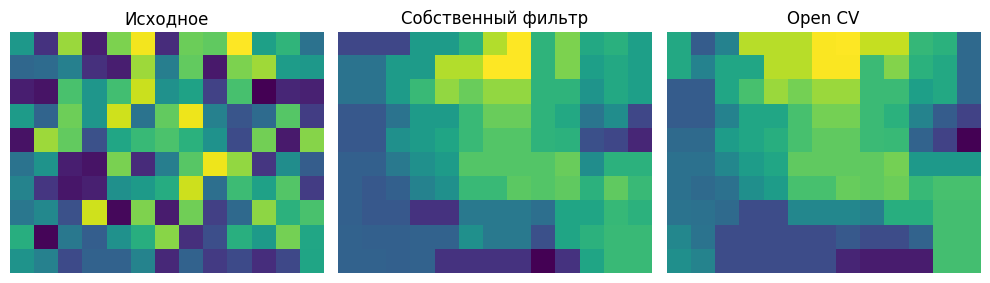

In [46]:
H = 1
W = 3
image_list = [arr_test, arr_my_med.squeeze(), arr_cv2_med]
label_list = ["Исходное", "Собственный фильтр", "Open CV"]
fig, ax = plt.subplots(H, W, figsize=(10,10))
if H == 1:
    for i in range(W):
        ax[i].imshow(image_list[i])  #, cmap='gray'
        ax[i].axis('off')
        ax[i].set_title(label_list[i])  
else:
    for i in range(H*W):
        h = i // W  
        w = i % W
        ax[h, w].imshow(image_list[i]) #, cmap='gray'
        ax[h, w].axis('off')
        ax[h, w].set_title(label_list[i])  

plt.tight_layout()
plt.show()

Собственный медианный фильтр работает
Значения для центральныйх элементов для собственного медианного фильтра и фильтра из бибилиотеки Open CV совпадают, различия есть только в крайних элементах, где ядро накладывается не полностью и число элементов в ядре оказывается равным чётному числу
В данном случае разработанный алгоритм выбирает меньшее из центральных значений, а в реализации библиотеки CV 2 более сложный алгоритм, который выбирает или меньшее или большее значение медианы при чётном числе элементов

In [47]:
sorce_image1 = mpimg.imread('../Sourse_Images/flowers_sm_sz3.jpg')#salt_paper0.jpg
filter_size = 7
#Собственный фильтр
myf_image1 = Median_filter(sorce_image1, filter_size, expand = 2)
#Фильтр CV2
cv2_image1 = cv2.medianBlur(sorce_image1, ksize=filter_size)

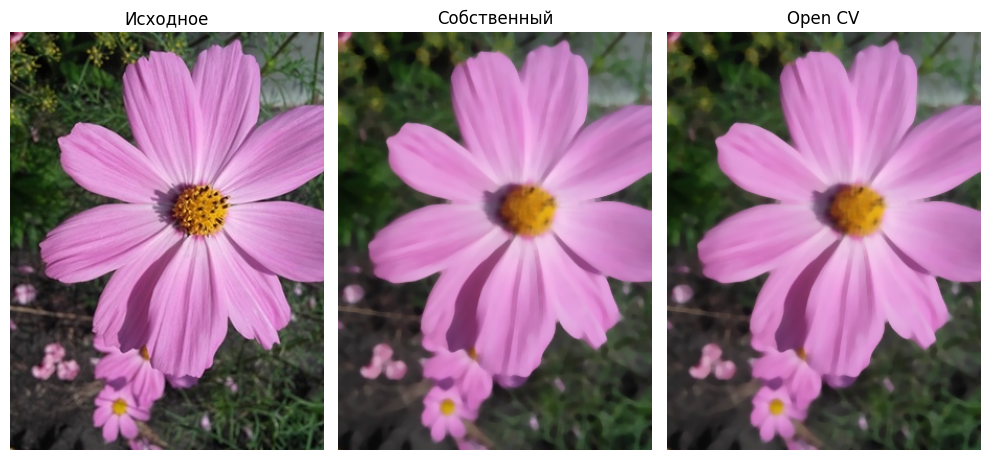

In [48]:
H = 1
W = 3
image_list = [sorce_image1, myf_image1, cv2_image1]
label_list = ["Исходное", "Собственный", "Open CV"]
fig, ax = plt.subplots(H, W, figsize=(10,10))
if H == 1:
    for i in range(W):
        ax[i].imshow(image_list[i])  #, cmap='gray'
        ax[i].axis('off')
        ax[i].set_title(label_list[i])  
else:
    for i in range(H*W):
        h = i // W  
        w = i % W
        ax[h, w].imshow(image_list[i])
        ax[h, w].axis('off')
        ax[h, w].set_title(label_list[i])  

plt.tight_layout()
plt.show()

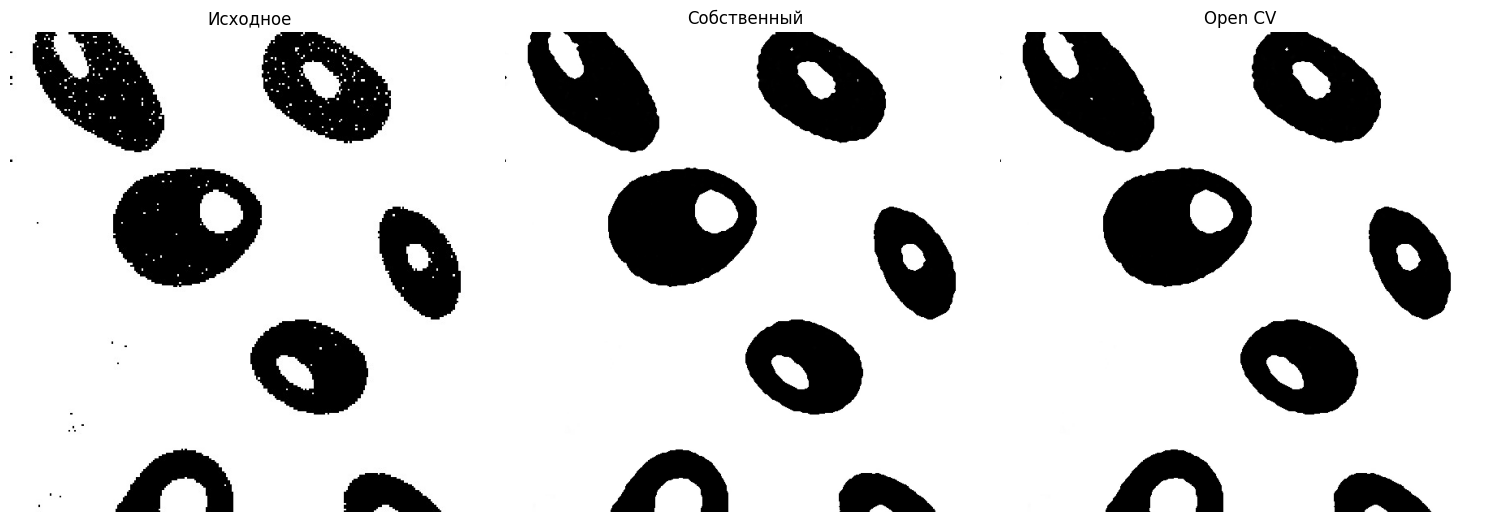

In [49]:
sorce_image2 = mpimg.imread('../Sourse_Images/salt_paper0.jpg')#flowers_sm_sz3.jpg
filter_size = 5
#Собственный фильтр
myf_image2 = Median_filter(sorce_image2, filter_size, expand = 2)
#Фильтр CV2
cv2_image2 = cv2.medianBlur(sorce_image2, ksize=filter_size)
H = 1
W = 3
image_list = [sorce_image2, myf_image2, cv2_image2]
label_list = ["Исходное", "Собственный", "Open CV"]
fig, ax = plt.subplots(H, W, figsize=(15,15))
if H == 1:
    for i in range(W):
        ax[i].imshow(image_list[i])  #, cmap='gray'
        ax[i].axis('off')
        ax[i].set_title(label_list[i])  
else:
    for i in range(H*W):
        h = i // W  
        w = i % W
        ax[h, w].imshow(image_list[i])
        ax[h, w].axis('off')
        ax[h, w].set_title(label_list[i])  

plt.tight_layout()
plt.show()

## 1.2 Фильтр гаусса

Данный фильтр обладает сепарабельностью, то есть может быть разделён на произведение двух векторов

Эмпирическое правило Трех сигм
радиус ядра должен быть не меньше, чем 3σ (три сигмы)
filtersize ≥ 2*(3*σ)+1 = 6*σ+1

In [50]:
@jit(nopython=True, parallel=True, cache=True)
def Gauss_filter(image: np.ndarray, filtersize: int = 3, sigma: float = 1, dupledge: bool = False, grout: bool = False, verbose: bool = False) -> np.ndarray:
    """
    image - исходное изображение массив np.ndarray (Н, W, C) H-высота, W - ширина, C - число каналов
    filtersize - размер стороны ядра свёртки, нечётное число
    sigma – стандартное отклонение нормального распределения;
    dupledge = True - расширение зеркалом с дублированием края
    dupledge = False  - расширение зеркалом без дублирования края
    verbose - вывод массивов, по которым происходит выбор
    grout - выбирать большее значение за медиану, только при expand = 0
    """
    
    if image is None or len(image.shape) != 3:
        raise ValueError("Изображение должно быть трехмерным массивом (H, W, C)")
    
    H, W, C = image.shape
    
    edge = 1
    if (filtersize % 2 and filtersize > 0):
        edge = (filtersize - 1) // 2
    else:
        ####Error
        raise ValueError("Размер ядра должен быть нечетным числом")
        # res_image = np.zeros((H, W, C))
    
    kernel = np.zeros((filtersize, filtersize))
    kernel_center = filtersize // 2
    
    koeff = 1 / (2 * np.pi * sigma * sigma)
    for i in prange(filtersize):
        for j in prange(filtersize):
            x = i - kernel_center
            y = j - kernel_center
            kernel[i, j] = koeff*np.exp(-(x*x+y*y)/(2*sigma*sigma))
    # Нормализация ядра свёртки
    kernel = kernel / np.sum(kernel)
    
    buf_image = np.zeros((H + 2 * edge, W + 2 * edge, C), dtype=np.uint8)  #  image.dtype
    buf_image[edge: H + edge, edge: W + edge, :] = image #image.copy()
    
    # Отражение границ
    if dupledge:
        bias = 0
    else:
        bias = 1      
    for ed in prange(1, edge+1):  
        for k in prange(C):
            buf_image[edge-ed:edge-ed+1,edge:W+edge] = image[ed-1+bias:ed+bias, :]
            buf_image[edge+H+ed-1:edge+H+ed,edge:W+edge] = image[H-ed-bias:H-ed+1-bias, :]
    for ed in prange(1, edge+1):  
        for k in prange(C):
            buf_image[:,edge-ed:edge-ed+1] = buf_image[:, edge+ed-1+bias:edge+ed+bias]
            buf_image[:,W+edge+ed-1:W+edge+ed] = buf_image[:, W+edge-ed-bias:W+edge-ed+1-bias]                
    
  
    #res_image = np.zeros((H, W, C), dtype=np.uint8)
    res_image = np.zeros_like(image)
    
    for i in prange(H):
        for j in prange(W):
            for k in prange(C):
                sub_array = buf_image[i:i + filtersize, j:j + filtersize, k]
                sum = np.round(np.sum(sub_array * kernel))
                #sub_array = buf_image[i:i + filtersize, j:j + filtersize, k:k+1]
                #sum = np.sum(sub_array.squeeze() * kernel
                if(sum > 255):
                    sum = 255
                elif(sum < 0):
                    sum = 0
                res_image[i, j, k] = sum #np.sum(product)
    return res_image.astype(np.uint8)



In [51]:
rng = np.random.default_rng(seed=42)# Создаем генератор случайных чисел
arr_test = rng.integers(0, 255, size=(10, 13, 1), dtype=np.uint8)
filter_size = 7
sigma = 1
print("Исходное")
print(arr_test.squeeze())
print("Собственный фильтр")
arr_my_med = Gauss_filter(arr_test, filter_size, sigma)
print(arr_my_med.squeeze())
print("Фильтр CV2")
arr_cv2_med= cv2.GaussianBlur(arr_test, ksize=(filter_size,filter_size), sigmaX=sigma)
print(arr_cv2_med)


Исходное
[[135  37 216  21 204 250  32 197 192 254 144 166  96]
 [ 85  89 111  35  21 217 109 193  17 204 218 140 135]
 [ 21  13 181 133 177 234 128 146  50 180   0  27  23]
 [139  82 198 133 236  97 193 248 112  67  89 187  46]
 [ 12 217 193  63 150 171 182 162 129  58 200  18 208]
 [ 97 130  21  13 203  31 109 188 248 213  40 125  75]
 [114  40  15  22 127 138 157 235  93 174 145 186  45]
 [101 119  63 236   5 205  19 199  48  87 211 163 181]
 [159   3 102  76 128 159 209  34  61 160 138 201 150]
 [130 112  57  80  80 114  29  80  43  57  33  55 149]]
Собственный фильтр
[[ 86  93 101  99 125 153 146 143 151 168 164 141 129]
 [ 79  89 104 107 130 155 150 140 137 149 144 123 112]
 [ 77  93 120 132 149 164 160 144 124 118 109  95  89]
 [ 98 114 135 144 156 163 167 158 130 110 102  98  95]
 [112 121 122 122 137 147 159 165 148 126 114 108 107]
 [102  98  85  89 114 129 147 166 163 146 128 117 113]
 [ 90  81  71  83 107 124 140 153 148 144 144 138 132]
 [ 90  83  83  97 111 126 130 124 11

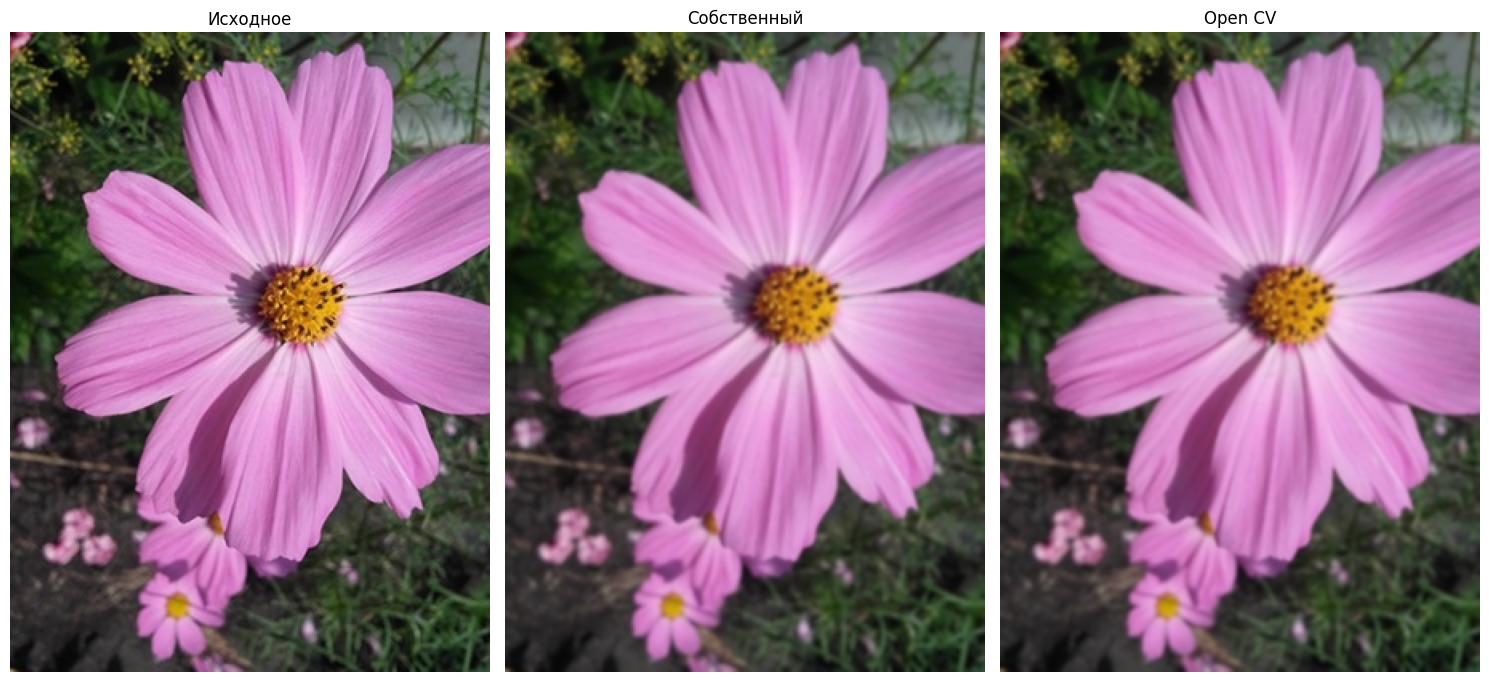

In [52]:
sorce_imageg = mpimg.imread('../Sourse_Images/flowers_sm_sz3.jpg')#.jpgsalt_paper0
filter_size = 7 #5 #13 #7
sigma = 1 #0.6 #2 #1
#Собственный фильтр
myf_imageg = Gauss_filter(sorce_imageg, filter_size, sigma)
#Фильтр CV2
cv2_imageg = cv2.GaussianBlur(sorce_imageg, ksize=(filter_size,filter_size), sigmaX=sigma)
H = 1
W = 3
image_list = [sorce_imageg, myf_imageg, cv2_imageg]
label_list = ["Исходное", "Собственный", "Open CV"]
fig, ax = plt.subplots(H, W, figsize=(15,15))
if H == 1:
    for i in range(W):
        ax[i].imshow(image_list[i])  #, cmap='gray'
        ax[i].axis('off')
        ax[i].set_title(label_list[i])  
else:
    for i in range(H*W):
        h = i // W  
        w = i % W
        ax[h, w].imshow(image_list[i])
        ax[h, w].axis('off')
        ax[h, w].set_title(label_list[i])  

plt.tight_layout()
plt.show()

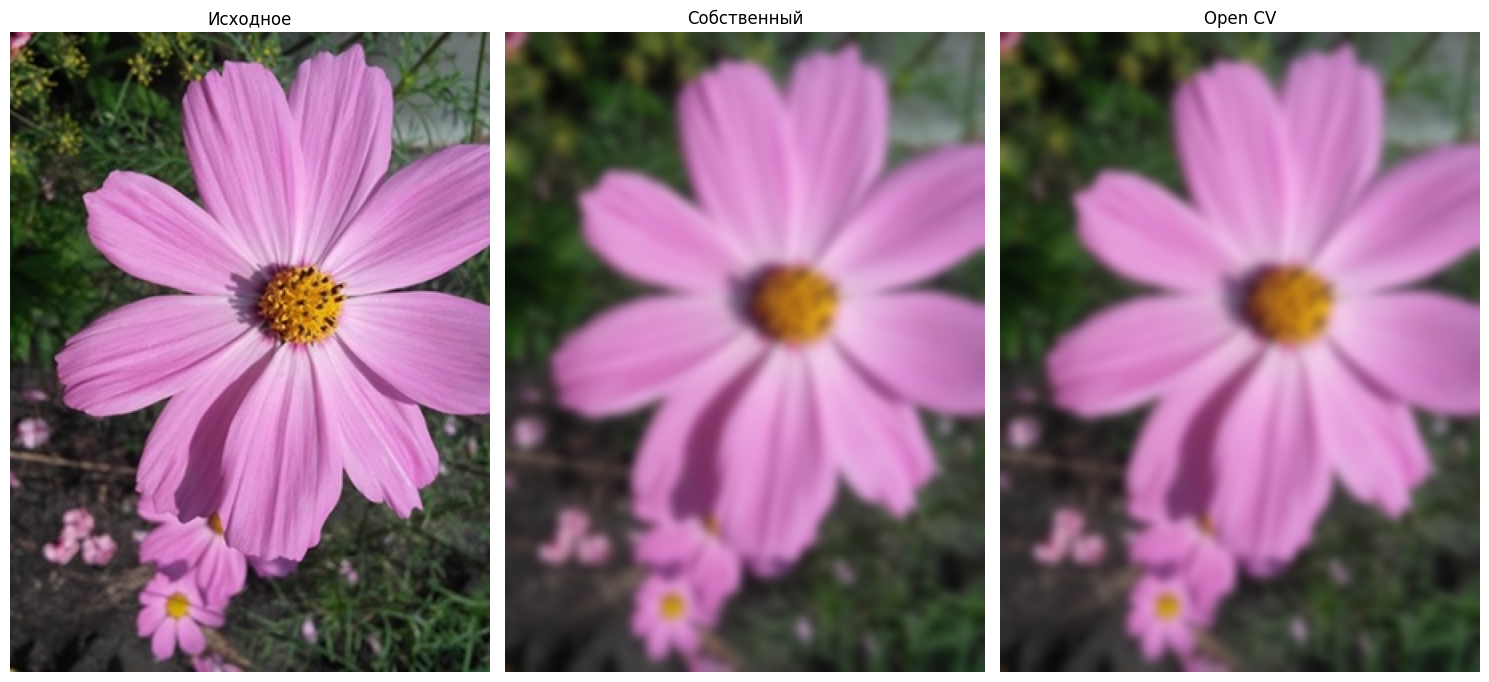

In [53]:
sorce_imageg = mpimg.imread('../Sourse_Images/flowers_sm_sz3.jpg')#.jpgsalt_paper0
filter_size = 19
sigma = 3
#Собственный фильтр
myf_imageg2 = Gauss_filter(sorce_imageg, filter_size, sigma)
#Фильтр CV2
cv2_imageg2 = cv2.GaussianBlur(sorce_imageg, ksize=(filter_size,filter_size), sigmaX=sigma)
H = 1
W = 3
image_list = [sorce_imageg, myf_imageg2, cv2_imageg2]
label_list = ["Исходное", "Собственный", "Open CV"]
fig, ax = plt.subplots(H, W, figsize=(15,15))
if H == 1:
    for i in range(W):
        ax[i].imshow(image_list[i])  #, cmap='gray'
        ax[i].axis('off')
        ax[i].set_title(label_list[i])  
else:
    for i in range(H*W):
        h = i // W  
        w = i % W
        ax[h, w].imshow(image_list[i])
        ax[h, w].axis('off')
        ax[h, w].set_title(label_list[i])  

plt.tight_layout()
plt.show()

# Морфологические операции

## 2.1 Эрозия

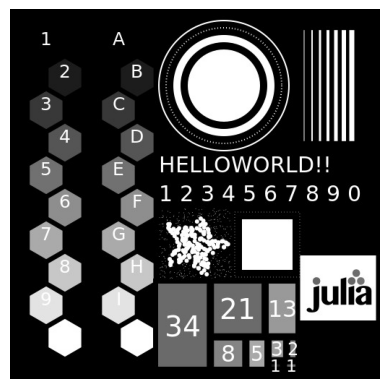

In [16]:
sorce_image4 = mpimg.imread('../Sourse_Images/erosion_dilatation.jpg')#flowers_sm_sz3.jpg
plt.imshow(sorce_image4)
plt.axis('off')  # скрыть оси
plt.show()

In [17]:
sorce_image4.shape

(512, 512, 3)

In [18]:
@jit(nopython=True, parallel=True, cache=True)
def image_binarization(image: np.ndarray, threshold: np.uint8 = 127) -> np.ndarray:
    "threshold: white (1) >= threshold"
    H = image.shape[0]
    W = image.shape[1]
    C = image.shape[2]

    res_image = np.zeros((H, W, C), dtype=image.dtype)  # dtype=image.dtype)
    for i in prange(H):
        for j in prange(W):
            for k in prange(C):
                if (image[i, j, k] > threshold):
                    res_image[i, j, k] = 1
                else:
                    res_image[i, j, k] = 0
    return res_image


(512, 512, 3)


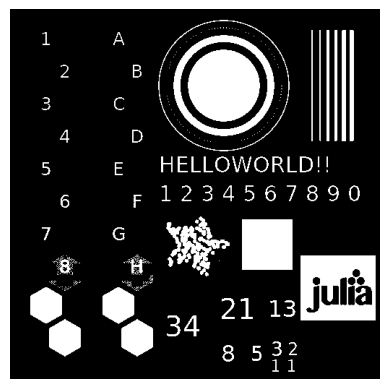

CPU times: total: 484 ms
Wall time: 52.3 ms


In [19]:
%%time
bin_image4 = image_binarization(sorce_image4, 200)
print(bin_image4.shape)
plt.imshow(bin_image4*255)
plt.axis('off')  # скрыть оси
plt.show()

In [20]:
@jit(nopython=True, parallel=True, cache=True)
def Erode(image: np.ndarray, filtersize: int = 3, dupledge: bool = False) -> np.ndarray:
    """
    image - исходное изображение массив np.ndarray (Н, W, C) H-высота, W - ширина, C - число каналов
    filtersize - размер стороны ядра свёртки, нечётное число
    dupledge = True - расширение зеркалом с дублированием края
    dupledge = False  - расширение зеркалом без дублирования края
    """
    if image is None or len(image.shape) != 3:
        raise ValueError("Изображение должно быть трехмерным массивом (H, W, C)")
    
    H, W, C = image.shape

    edge = 1
    if (filtersize % 2 and filtersize > 0):
        edge = (filtersize - 1) // 2
    else:
        ####Error
        raise ValueError("Размер ядра должен быть нечетным числом")

    kernel = np.ones((filtersize, filtersize))
    
    filt_sum = filtersize*filtersize #np.sum(kernel)

    buf_image = np.zeros((H + 2 * edge, W + 2 * edge, C), dtype=np.uint8)  #  image.dtype
    buf_image[edge: H + edge, edge: W + edge, :] = image #image.copy()

    if dupledge:
        bias = 0
    else:
        bias = 1      
    for ed in range(1, edge+1):  
        for k in range(C):
            buf_image[edge-ed:edge-ed+1,edge:W+edge] = image[ed-1+bias:ed+bias, :]
            buf_image[edge+H+ed-1:edge+H+ed,edge:W+edge] = image[H-ed-bias:H-ed+1-bias, :]
    for ed in range(1, edge+1):  
        for k in range(C):
            buf_image[:,edge-ed:edge-ed+1] = buf_image[:, edge+ed-1+bias:edge+ed+bias]
            buf_image[:,W+edge+ed-1:W+edge+ed] = buf_image[:, W+edge-ed-bias:W+edge-ed+1-bias]                

    res_image = np.zeros((H, W, C), dtype=np.uint8)  # dtype=image.dtype)
    for i in range(H):
        for j in range(W):
            for k in range(C):
                sub_array = buf_image[i:i + filtersize, j:j + filtersize, k]
                sum = np.sum(sub_array * kernel)
                if (sum == filt_sum):
                    res_image[i, j, k] = 1
                else:
                    res_image[i, j, k] = 0
    return res_image

In [21]:
rng = np.random.default_rng(seed=42)# Создаем генератор случайных чисел
arr_test_f = rng.integers(0, 255, size=(10, 13, 1), dtype=np.uint8)
arr_test = image_binarization(arr_test_f, 127)
filter_size = 3
print("Исходное")
print(arr_test.squeeze())
print("Собственный фильтр")
%time arr_my_med = Erode(arr_test, filtersize = filter_size)
print(arr_my_med.squeeze())
kernel = np.ones((filter_size,filter_size), np.uint8)
print("Фильтр CV2")
%time arr_cv2_med= cv2.erode(arr_test, kernel)
print(arr_cv2_med)

Исходное
[[1 0 1 0 1 1 0 1 1 1 1 1 0]
 [0 0 0 0 0 1 0 1 0 1 1 1 1]
 [0 0 1 1 1 1 1 1 0 1 0 0 0]
 [1 0 1 1 1 0 1 1 0 0 0 1 0]
 [0 1 1 0 1 1 1 1 1 0 1 0 1]
 [0 1 0 0 1 0 0 1 1 1 0 0 0]
 [0 0 0 0 0 1 1 1 0 1 1 1 0]
 [0 0 0 1 0 1 0 1 0 0 1 1 1]
 [1 0 0 0 1 1 1 0 0 1 1 1 1]
 [1 0 0 0 0 0 0 0 0 0 0 0 1]]
Собственный фильтр
CPU times: total: 844 ms
Wall time: 48.5 ms
[[0 0 0 0 0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0]]
Фильтр CV2
CPU times: total: 0 ns
Wall time: 4.5 ms
[[0 0 0 0 0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0]]


CPU times: total: 2min 39s
Wall time: 10.6 s
CPU times: total: 0 ns
Wall time: 1e+03 μs


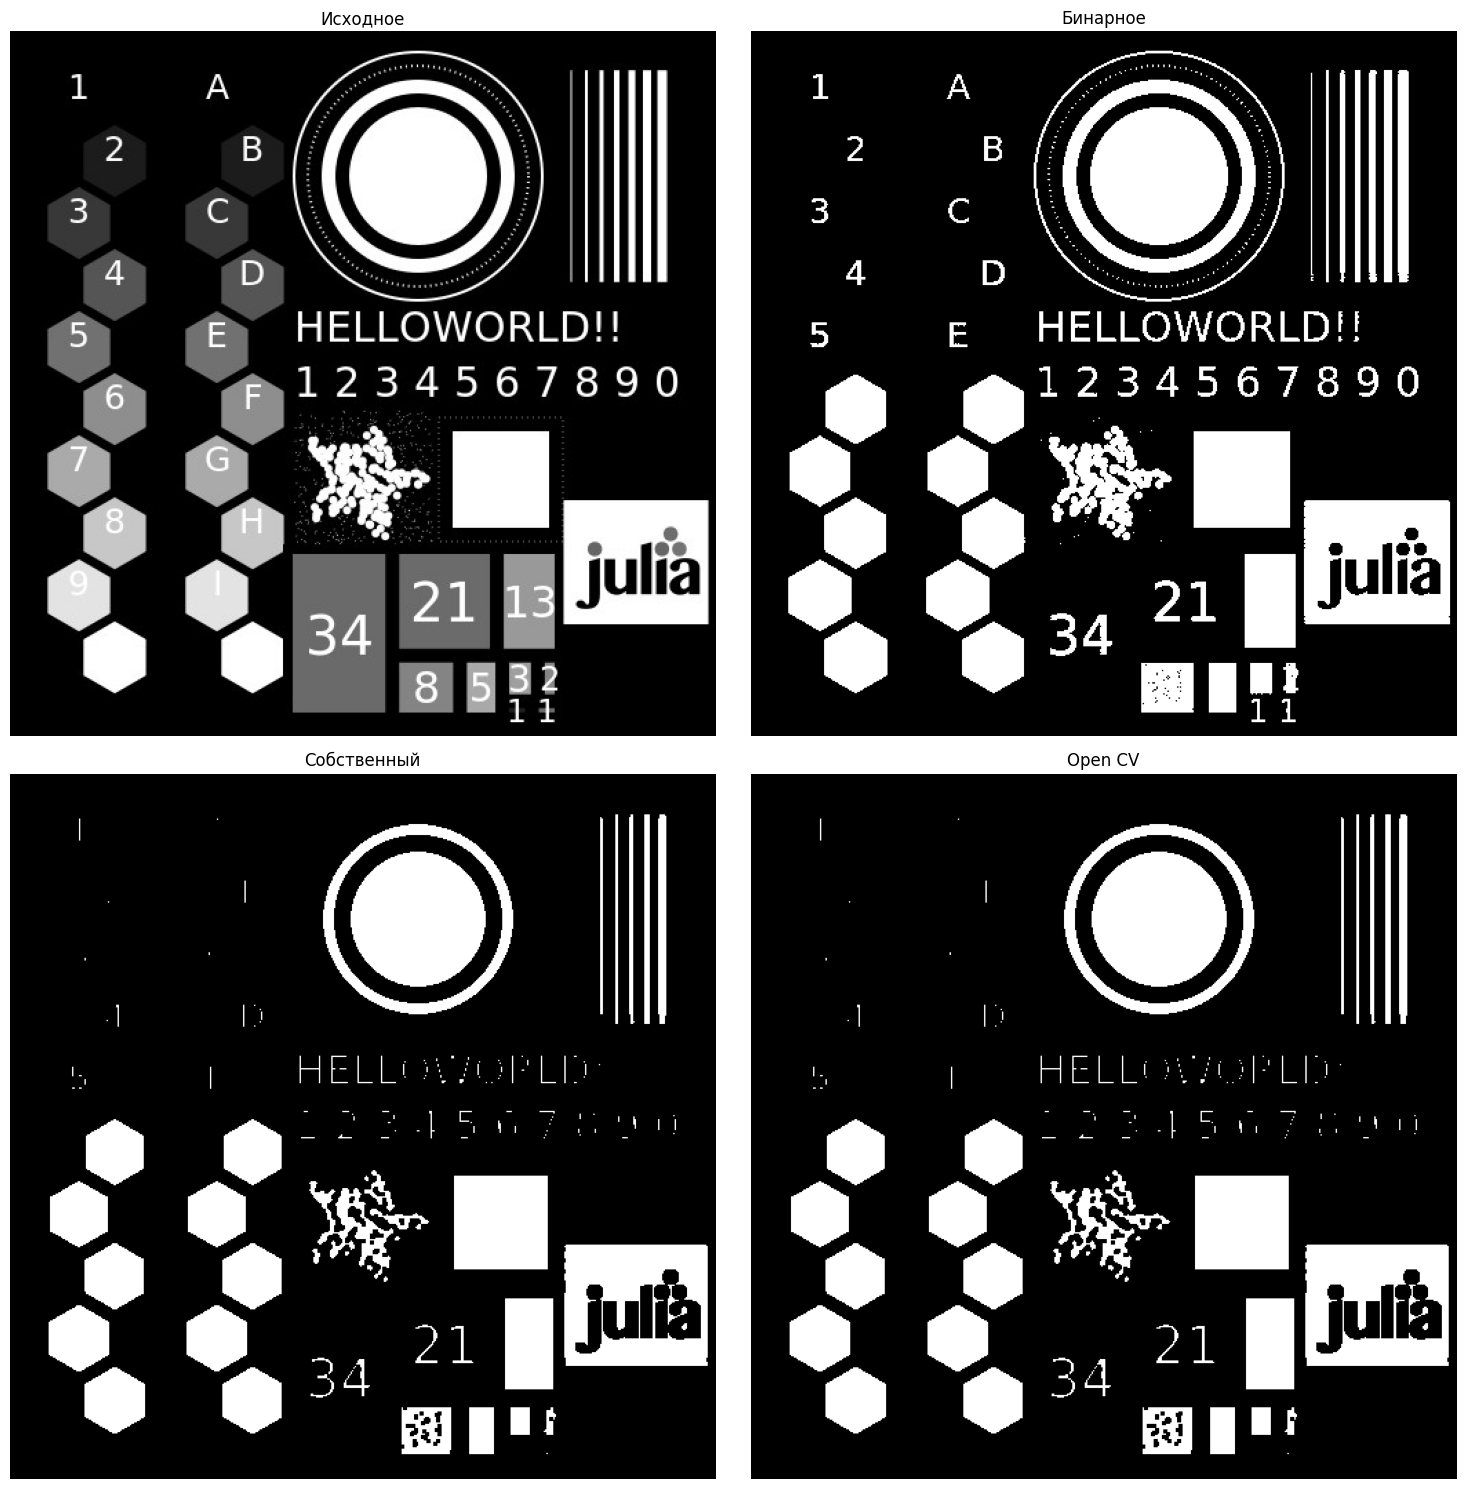

CPU times: total: 2min 41s
Wall time: 10.8 s


In [22]:
%%time
sorce_image4 = mpimg.imread('../Sourse_Images/erosion_dilatation.jpg')#flowers_sm_sz3.jpg
filter_size = 3 #5 #13 #7
bin_image4 = image_binarization(sorce_image4, 127)
#Собственный фильтр
%time myf_image4 = Erode(bin_image4, filtersize = filter_size)
#Фильтр CV2
kernel = np.ones((filter_size,filter_size), np.uint8)
%time cv2_image4 = cv2.erode(bin_image4, kernel)
scale = 255
H = 2
W = 2
image_list = [sorce_image4, bin_image4*scale, myf_image4*scale, cv2_image4*scale]
label_list = ["Исходное", "Бинарное", "Собственный", "Open CV"]
fig, ax = plt.subplots(H, W, figsize=(15,15))
if H == 1:
    for i in range(W):
        ax[i].imshow(image_list[i])  #, cmap='gray'
        ax[i].axis('off')
        ax[i].set_title(label_list[i])  
else:
    for i in range(H*W):
        h = i // W  
        w = i % W
        ax[h, w].imshow(image_list[i])
        ax[h, w].axis('off')
        ax[h, w].set_title(label_list[i])  

plt.tight_layout()
plt.show()

## 2.2 Делатация

In [23]:
@jit(nopython=True, parallel=True, cache=True)
def Dilate(image: np.ndarray, filtersize: int = 3, dupledge: bool = False) -> np.ndarray:
    """
    image - исходное изображение массив np.ndarray (Н, W, C) H-высота, W - ширина, C - число каналов
    filtersize - размер стороны ядра свёртки, нечётное число
    dupledge = True - расширение зеркалом с дублированием края
    dupledge = False  - расширение зеркалом без дублирования края
    """
    if image is None or len(image.shape) != 3:
        raise ValueError("Изображение должно быть трехмерным массивом (H, W, C)")
    
    H, W, C = image.shape

    edge = 1
    if (filtersize % 2 and filtersize > 0):
        edge = (filtersize - 1) // 2
    else:
        ####Error
        raise ValueError("Размер ядра должен быть нечетным числом")

    kernel = np.ones((filtersize, filtersize))
    
    buf_image = np.zeros((H + 2 * edge, W + 2 * edge, C), dtype=np.uint8)  #  image.dtype
    buf_image[edge: H + edge, edge: W + edge, :] = image #image.copy()

    if dupledge:
        bias = 0
    else:
        bias = 1      
    for ed in range(1, edge+1):  
        for k in range(C):
            buf_image[edge-ed:edge-ed+1,edge:W+edge] = image[ed-1+bias:ed+bias, :]
            buf_image[edge+H+ed-1:edge+H+ed,edge:W+edge] = image[H-ed-bias:H-ed+1-bias, :]
    for ed in range(1, edge+1):  
        for k in range(C):
            buf_image[:,edge-ed:edge-ed+1] = buf_image[:, edge+ed-1+bias:edge+ed+bias]
            buf_image[:,W+edge+ed-1:W+edge+ed] = buf_image[:, W+edge-ed-bias:W+edge-ed+1-bias]                

    res_image = np.zeros((H, W, C), dtype=np.uint8)  # dtype=image.dtype)
    for i in range(H):
        for j in range(W):
            for k in range(C):
                sub_array = buf_image[i:i + filtersize, j:j + filtersize, k]
                sum = np.sum(sub_array * kernel)
                if (sum > 0):
                    res_image[i, j, k] = 1
                else:
                    res_image[i, j, k] = 0
    return res_image

CPU times: total: 2min 31s
Wall time: 10.4 s
CPU times: total: 0 ns
Wall time: 1 ms


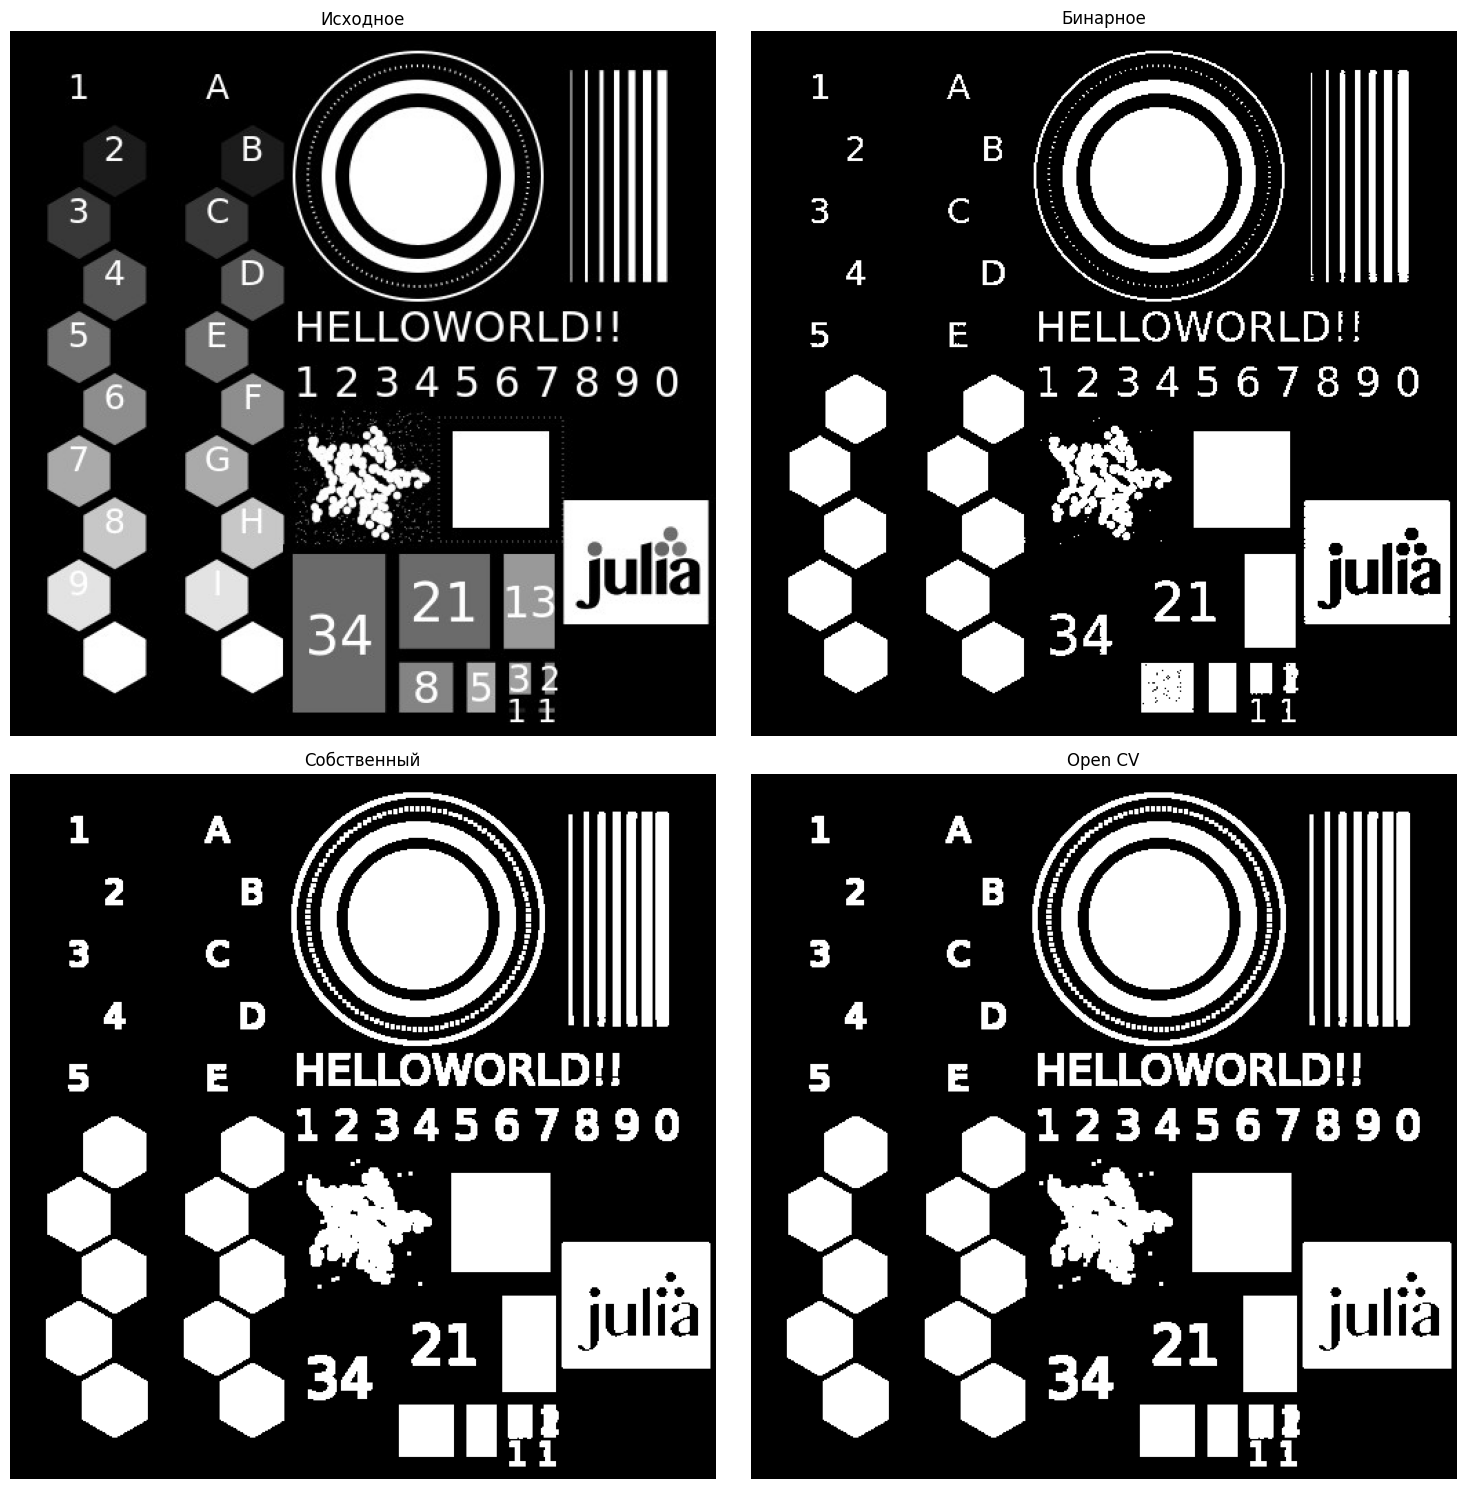

CPU times: total: 2min 33s
Wall time: 10.7 s


In [24]:
%%time
sorce_image4 = mpimg.imread('../Sourse_Images/erosion_dilatation.jpg')#flowers_sm_sz3.jpg
filter_size = 3 #5 #13 #7
bin_image4 = image_binarization(sorce_image4, 127)
#Собственный фильтр
%time myf_image4 = Dilate(bin_image4, filtersize = filter_size)
#Фильтр CV2
kernel = np.ones((filter_size,filter_size), np.uint8)
%time cv2_image4 = cv2.dilate(bin_image4, kernel)
scale = 255
H = 2
W = 2
image_list = [sorce_image4, bin_image4*scale, myf_image4*scale, cv2_image4*scale]
label_list = ["Исходное", "Бинарное", "Собственный", "Open CV"]
fig, ax = plt.subplots(H, W, figsize=(15,15))
if H == 1:
    for i in range(W):
        ax[i].imshow(image_list[i])  #, cmap='gray'
        ax[i].axis('off')
        ax[i].set_title(label_list[i])  
else:
    for i in range(H*W):
        h = i // W  
        w = i % W
        ax[h, w].imshow(image_list[i])
        ax[h, w].axis('off')
        ax[h, w].set_title(label_list[i])  

plt.tight_layout()
plt.show()

# 3. Прочие операции

## 3.1 пороговая бинаризация (для rgb и grayscale изображения)

In [25]:
@jit(nopython=True, parallel=True, cache=True)
def image_binarization(image: np.ndarray, threshold: np.uint8 = 127) -> np.ndarray:
    "threshold: white (1) >= threshold"
    H = image.shape[0]
    W = image.shape[1]
    C = image.shape[2]

    res_image = np.zeros((H, W, C), dtype=image.dtype)  # dtype=image.dtype)
    for i in prange(H):
        for j in prange(W):
            for k in prange(C):
                if (image[i, j, k] > threshold):
                    res_image[i, j, k] = 1
                else:
                    res_image[i, j, k] = 0
    return res_image

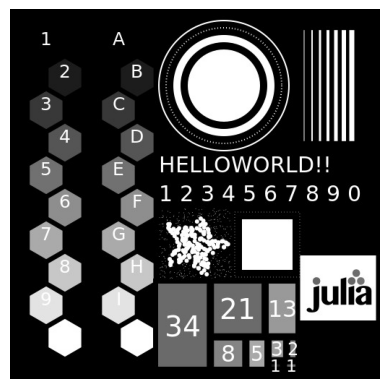

In [26]:
sorce_image4 = mpimg.imread('../Sourse_Images/erosion_dilatation.jpg')#flowers_sm_sz3.jpg
plt.imshow(sorce_image4)
plt.axis('off')  # скрыть оси
plt.show()

(512, 512, 3)


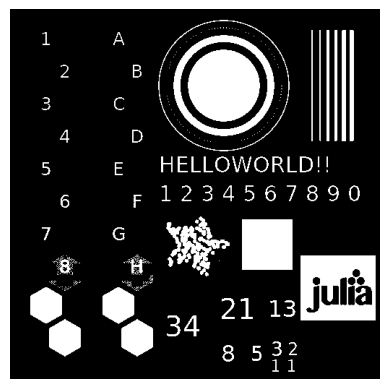

CPU times: total: 344 ms
Wall time: 57.1 ms


In [27]:
%%time
bin_image4 = image_binarization(sorce_image4, 200)
print(bin_image4.shape)
plt.imshow(bin_image4*255)
plt.axis('off')  # скрыть оси
plt.show()

(400, 300, 3)


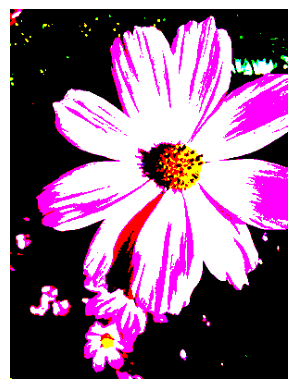

CPU times: total: 188 ms
Wall time: 25.5 ms


In [28]:
%%time
sorce_image5 = mpimg.imread('../Sourse_Images/flowers_sm_sz3.jpg')
bin_image5 = image_binarization(sorce_image5, 127)
print(bin_image5.shape)
plt.imshow(bin_image5*255)
plt.axis('off')  # скрыть оси
plt.show()

(400, 300, 3)


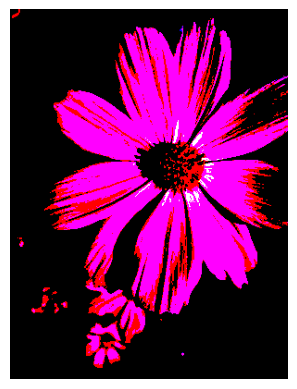

CPU times: total: 172 ms
Wall time: 25 ms


In [29]:
%%time
sorce_image5 = mpimg.imread('../Sourse_Images/flowers_sm_sz3.jpg')
bin_image5 = image_binarization(sorce_image5, 200)
print(bin_image5.shape)
plt.imshow(bin_image5*255)
plt.axis('off')  # скрыть оси
plt.show()

(400, 300, 3)


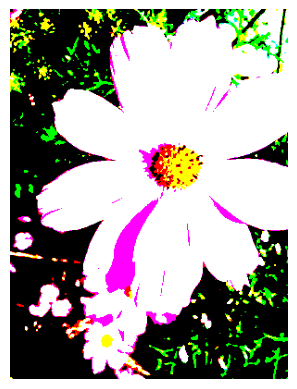

CPU times: total: 344 ms
Wall time: 29.1 ms


In [30]:
%%time
sorce_image5 = mpimg.imread('../Sourse_Images/flowers_sm_sz3.jpg')
bin_image5 = image_binarization(sorce_image5, 80)
print(bin_image5.shape)
plt.imshow(bin_image5*255)
plt.axis('off')  # скрыть оси
plt.show()

## 3.2 Выравнивание гистограммы освещения

In [31]:
from matplotlib.pyplot import hist

In [32]:
@jit(nopython=True, parallel=True, cache=True)
def Light_Equal(image: np.ndarray) -> np.ndarray:

    hist_bincount = np.bincount(image.ravel(), minlength=256)
    #hist_histogram, _ = np.histogram(image.ravel(), bins=256, range=[0, 256])
    band = 50
    nonzero_indices = np.nonzero(hist_bincount)[0]
    min_light_s = nonzero_indices[0]
    max_light_s = nonzero_indices[-1]
    mediam_light = np.argmax(hist_bincount)
    min_light = max(mediam_light - band, min_light_s)
    max_light = min(mediam_light + band, max_light_s)
    clipped = np.clip(image, min_light, max_light)
    img_stretched = (clipped - min_light) / (max_light - min_light) * 255
    img_stretched = np.clip(img_stretched, 0, 255).astype(np.uint8)

    return img_stretched

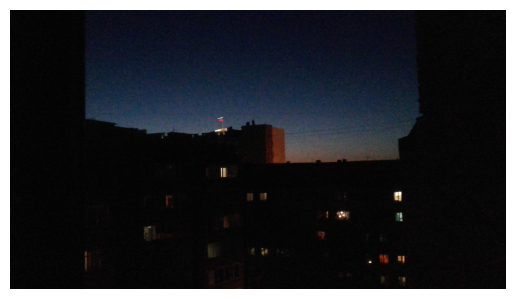

In [33]:
sorce_image6 = mpimg.imread('../Sourse_Images/night.jpg')
#sorce_image6 = mpimg.imread('../Sourse_Images/T_light.jpg')
plt.imshow(sorce_image6) #plt.imshow(image1)
plt.axis('off')  # скрыть оси
plt.show()

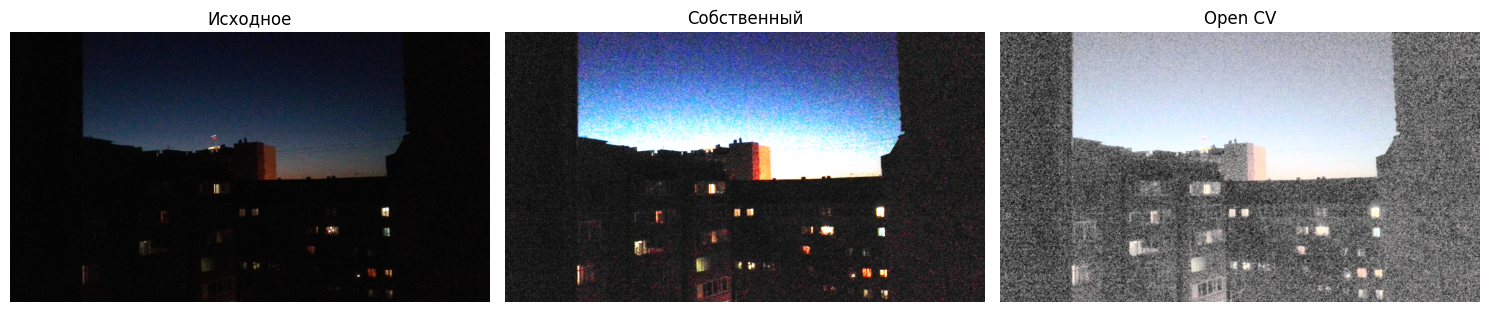

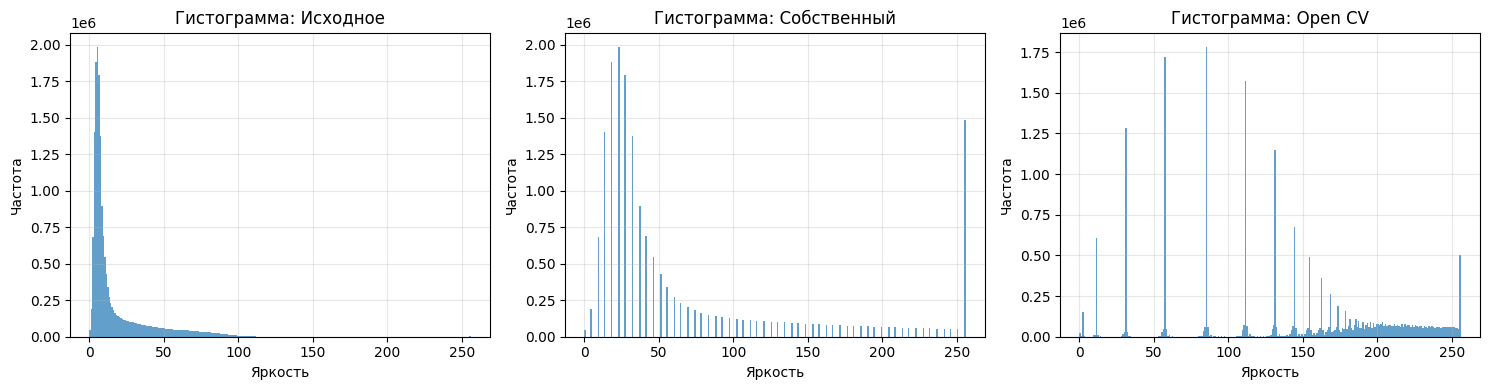

CPU times: total: 3.17 s
Wall time: 1.68 s


In [34]:
%%time
sorce_image6 = mpimg.imread('../Sourse_Images/night.jpg')
#Собственный фильтр
myf_image6 = Light_Equal(sorce_image6)
#Фильтр CV2
yuv = cv2.cvtColor(sorce_image6, cv2.COLOR_RGB2YUV)
yuv[:,:,0] = cv2.equalizeHist(yuv[:,:,0])
cv2_image6 = cv2.cvtColor(yuv, cv2.COLOR_YUV2RGB)
H = 1
W = 3
image_list = [sorce_image6, myf_image6, cv2_image6]
label_list = ["Исходное", "Собственный", "Open CV"]
fig, ax = plt.subplots(H, W, figsize=(15,15))
if H == 1:
    for i in range(W):
        ax[i].imshow(image_list[i])  #, cmap='gray'
        ax[i].axis('off')
        ax[i].set_title(label_list[i])  
else:
    for i in range(H*W):
        h = i // W  
        w = i % W
        ax[h, w].imshow(image_list[i])
        ax[h, w].axis('off')
        ax[h, w].set_title(label_list[i])  

plt.tight_layout()
plt.show()

fig2, axes2 = plt.subplots(H, W, figsize=(15, 4))

if H == 1:
    for i in range(W):
        # Исправлено: используем axes2[i] вместо ax[i]
        axes2[i].hist(image_list[i].ravel(), bins=256, range=(0, 256), alpha=0.7)
        axes2[i].set_title(f'Гистограмма: {label_list[i]}')
        axes2[i].set_xlabel('Яркость')
        axes2[i].set_ylabel('Частота')
        axes2[i].grid(True, alpha=0.3)
else:
    for i in range(H*W):
        h = i // W
        w = i % W
        axes2[h, w].hist(image_list[i].ravel(), bins=256, range=(0, 256), alpha=0.7)
        axes2[h, w].set_title(f'Гистограмма: {label_list[i]}')
        axes2[h, w].set_xlabel('Яркость')
        axes2[h, w].set_ylabel('Частота')
        axes2[h, w].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

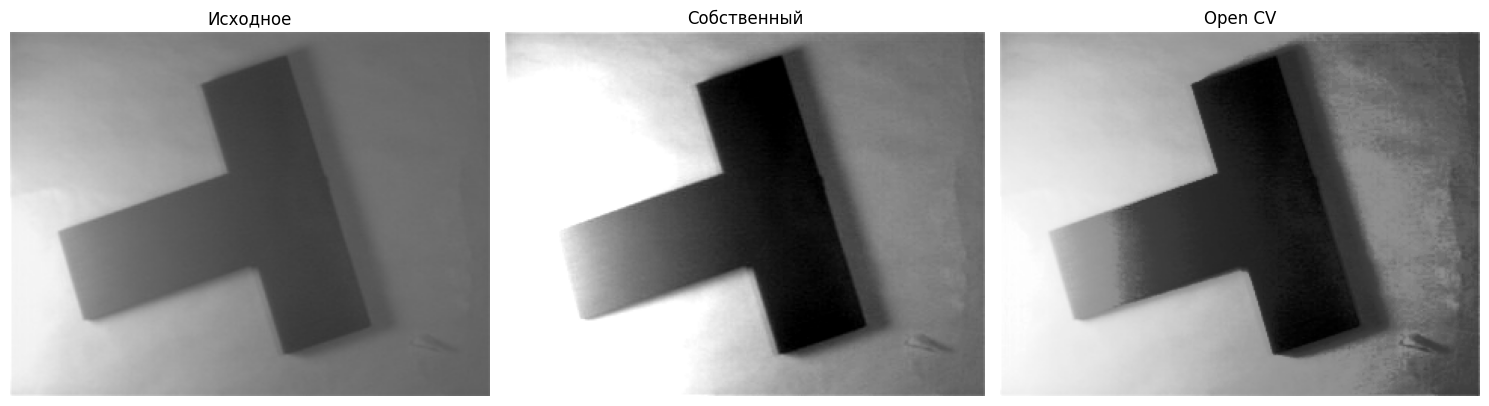

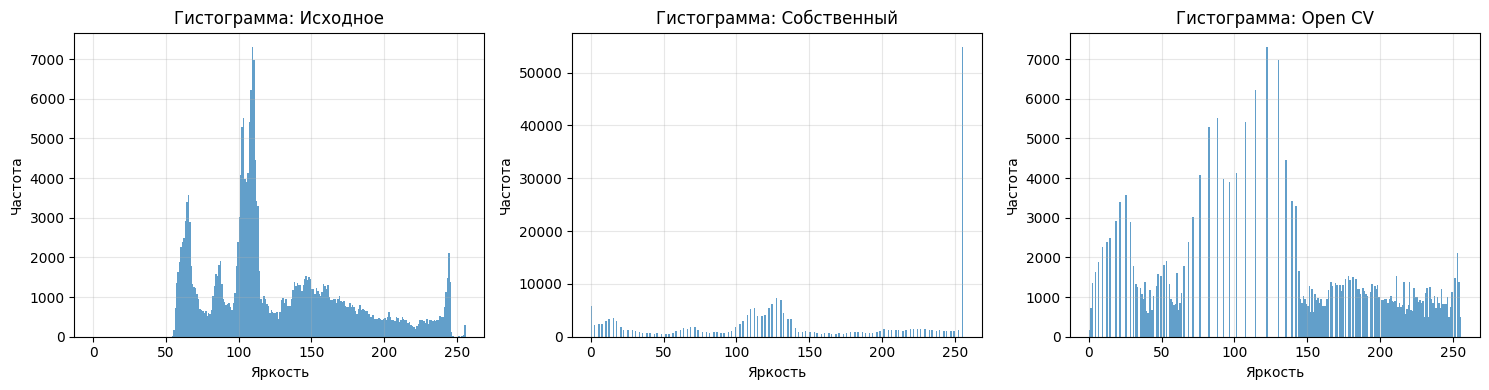

CPU times: total: 1.86 s
Wall time: 650 ms


In [35]:
%%time
sorce_image7 = mpimg.imread('../Sourse_Images/T_light.jpg')
#Собственный фильтр
myf_image7 = Light_Equal(sorce_image7)
#Фильтр CV2
yuv = cv2.cvtColor(sorce_image7, cv2.COLOR_RGB2YUV)
yuv[:,:,0] = cv2.equalizeHist(yuv[:,:,0])
cv2_image7 = cv2.cvtColor(yuv, cv2.COLOR_YUV2RGB)
H = 1
W = 3
image_list = [sorce_image7, myf_image7, cv2_image7]
label_list = ["Исходное", "Собственный", "Open CV"]
fig, ax = plt.subplots(H, W, figsize=(15,15))
if H == 1:
    for i in range(W):
        ax[i].imshow(image_list[i])  #, cmap='gray'
        ax[i].axis('off')
        ax[i].set_title(label_list[i])  
else:
    for i in range(H*W):
        h = i // W  
        w = i % W
        ax[h, w].imshow(image_list[i])
        ax[h, w].axis('off')
        ax[h, w].set_title(label_list[i])  

plt.tight_layout()
plt.show()

fig2, axes2 = plt.subplots(H, W, figsize=(15, 4))

if H == 1:
    for i in range(W):
        # Исправлено: используем axes2[i] вместо ax[i]
        axes2[i].hist(image_list[i].ravel(), bins=256, range=(0, 256), alpha=0.7)
        axes2[i].set_title(f'Гистограмма: {label_list[i]}')
        axes2[i].set_xlabel('Яркость')
        axes2[i].set_ylabel('Частота')
        axes2[i].grid(True, alpha=0.3)
else:
    for i in range(H*W):
        h = i // W
        w = i % W
        axes2[h, w].hist(image_list[i].ravel(), bins=256, range=(0, 256), alpha=0.7)
        axes2[h, w].set_title(f'Гистограмма: {label_list[i]}')
        axes2[h, w].set_xlabel('Яркость')
        axes2[h, w].set_ylabel('Частота')
        axes2[h, w].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3.3 Поворот изображения на угол кратный 90&deg;

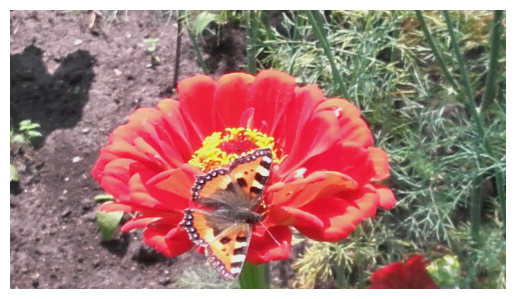

In [36]:
image1 = mpimg.imread('../Sourse_Images/butterfly_on_a_flower.jpg')#salt_paper0.jpg
plt.imshow(image1)
plt.axis('off')  # скрыть оси
plt.show()

In [37]:
def Rotate(image: np.ndarray, angle: int) -> np.ndarray:
    H = image.shape[0]
    W = image.shape[1]
    C = image.shape[2]
    angle = angle % 360
    if(angle == 0):
        res_image = image.copy()
    elif(angle == 90):
        res_image = np.zeros((W, H, C)) # dtype=image.dtype)
        for k in range(C):
            for i in range(W):
                for j in range(H):
                    res_image[i][j][k] = image[j][i][k]
    elif(angle == 180):
        res_image = np.zeros((H, W, C)) # dtype=image.dtype)
        for k in range(C):
            for i in range(H):
                for j in range(W):
                    res_image[i, j, k] = image[H-1-i,W-1-j,k]
    elif(angle == 270): 
        res_image = np.zeros((W, H, C)) # dtype=image.dtype)
        for k in range(C):
            for i in range(W):
                for j in range(H):                               
                    res_image[i, j, k] = image[H-1-j,i,k]
    else:
        ####Error
        res_image = np.zeros((H, W, C))
    
    return res_image.astype(np.uint8)


In [38]:
rotated_image = []
for i in [0, 90, 180, 270]:
    rotated_image.append(Rotate(image1, i))

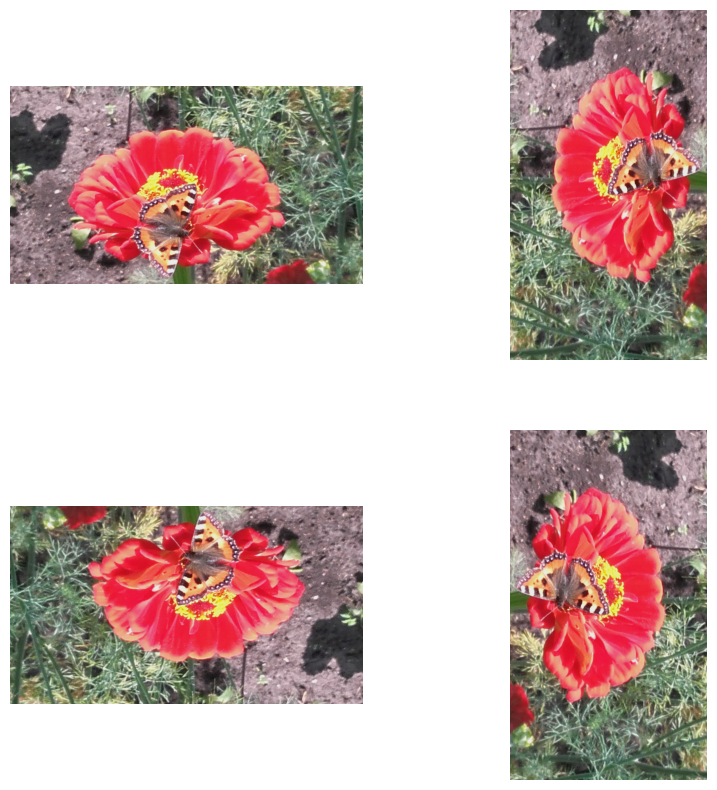

In [39]:
H = 2
W = 2
fig, ax = plt.subplots(H, W, figsize=(10,10))
for i in range(H*W):
    h = i // W
    w = i % W
    ax[h, w].imshow(rotated_image[i])
    ax[h, w].axis('off')
plt.show()

In [40]:
#cv2.imwrite('output.jpg', image)